In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!ls "/content/drive/MyDrive"

 180DC.pdf
 2024052084.pdf
 2024.gdoc
'Adobe Scan 04-Feb-2026 (1)-1.pdf'
'Adobe Scan 05-Feb-2026.pdf'
 Classroom
'Colab Notebooks'
'Copy of Understanding Pollution and Solutions.gslides'
'Daksh khatri(1696) (1).gdoc'
'Daksh khatri(1696) (2).gdoc'
'Daksh khatri(1696).gdoc'
 dataset_RideShield.zip
 dbms_lab10_dakshKhatri.gdoc
 DE.pdf
 DOC-20250411-WA0032..pdf
'DSA ASSIGNMENT .gdoc'
'epsilon constraint method.pdf'
'gate smashers.gdoc'
'Google Keep Document (1).gdoc'
'Google Keep Document (2).gdoc'
'Google Keep Document (3).gdoc'
'Google Keep Document (4).gdoc'
'Google Keep Document (5).gdoc'
'Google Keep Document (6).gdoc'
'Google Keep Document.gdoc'
'https:  admportal.iiit.ac.in do.php?NBPe966VC1VZS4I+ARdrv7OBGmQkHjaqFISEyRFdyVKcMcgTwTGM7yAfDqNuQkvg5i5BIyN4XXvJN5+ueNt0MS4askCSaOLW7WBcni7f5OG0GmifwPZU8PjyQXuyX8rt.pdf'
'https:  jeemain.ntaonline.in frontend web advancecityintimationslip admit-card.pdf'
'https:  jeemainsession2.ntaonline.in frontend web advancecityintimationslip admit-card.

In [3]:
!unzip "/content/drive/MyDrive/dataset_RideShield.zip" -d "/content/"

Archive:  /content/drive/MyDrive/dataset_RideShield.zip
   creating: /content/dataset/
   creating: /content/dataset/test/
   creating: /content/dataset/test/helmet/
  inflating: /content/dataset/test/helmet/helmet_103.jpg  
  inflating: /content/dataset/test/helmet/helmet_120.jpg  
  inflating: /content/dataset/test/helmet/helmet_122.jpg  
  inflating: /content/dataset/test/helmet/helmet_125.jpg  
  inflating: /content/dataset/test/helmet/helmet_127.jpg  
  inflating: /content/dataset/test/helmet/helmet_138.jpg  
  inflating: /content/dataset/test/helmet/helmet_14.jpg  
  inflating: /content/dataset/test/helmet/helmet_15.jpg  
  inflating: /content/dataset/test/helmet/helmet_159.jpg  
  inflating: /content/dataset/test/helmet/helmet_162.jpg  
  inflating: /content/dataset/test/helmet/helmet_164.jpg  
  inflating: /content/dataset/test/helmet/helmet_170.jpg  
  inflating: /content/dataset/test/helmet/helmet_171.jpg  
  inflating: /content/dataset/test/helmet/helmet_179.jpg  
  inflatin

In [4]:
!ls "/content/dataset"

test  train  val


In [5]:
!ls "/content/dataset/train"

helmet	no_helmet


including all dependencies

In [6]:
import torch
from torch import nn
import matplotlib.pyplot as plt
print(torch.__version__)

2.11.0+cu128


In [7]:
from torchvision import datasets,transforms
from torch.utils.data import dataloader

In [8]:
device="cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [9]:
from torchvision import transforms

train_transform=transforms.Compose([
    transforms.Resize((128,128)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])
test_transform=transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor()
])

In [10]:
from torchvision import datasets

train_data=datasets.ImageFolder(
    root="/content/dataset/train",
    transform=train_transform
)
val_data = datasets.ImageFolder(
    root="/content/dataset/val",
    transform=test_transform
)

test_data = datasets.ImageFolder(
    root="/content/dataset/test",
    transform=test_transform
)

In [11]:
len(test_data),len(train_data),len(val_data)

(217, 1003, 214)

In [12]:
torch.manual_seed(42)
from torch.utils.data import DataLoader

train_dataloader=DataLoader(
    dataset=train_data,
    batch_size=32,
    shuffle=True
)
val_dataloader=DataLoader(
    dataset=val_data,
    batch_size=32,
    shuffle=False
)
test_dataloader=DataLoader(
    dataset=test_data,
    batch_size=32,
    shuffle=False
)

In [13]:
image,label=next(iter(train_dataloader))
print(image.shape)
print(label.shape)

torch.Size([32, 3, 128, 128])
torch.Size([32])


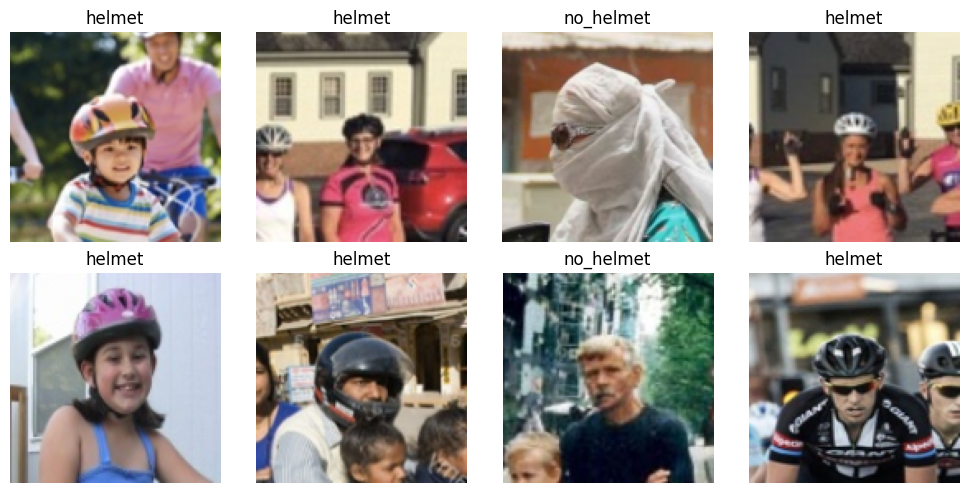

In [14]:
import matplotlib.pyplot as plt
# torch.manual_seed(42)
images, labels = next(iter(train_dataloader))

fig, axes = plt.subplots(2, 4, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    img = images[i].permute(1, 2, 0)  # CHW -> HWC

    ax.imshow(img)

    ax.set_title(train_data.classes[labels[i]])
    ax.axis("off")

plt.tight_layout()
plt.show()

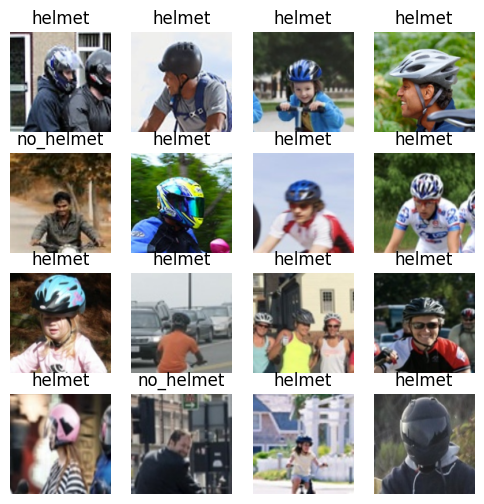

In [15]:
##printing random data
row,col=4,4
torch.manual_seed(42)
fig=plt.figure(figsize=(6,6))
for i in range(1,row*col+1): # Loop only for row*col images
  rand_idx=torch.randint(0,len(train_data),size=[1])
  img,label=train_data[rand_idx.item()]
  fig.add_subplot(row,col,i)
  plt.imshow(img.permute(1, 2, 0))
  plt.title(train_data.classes[label])
  plt.axis(False)

###Training our first model from scratch

In [16]:
class Helmvision(nn.Module):
  def __init__(self,input_shape:int,hidden_units:int,output_shape:int):
    super().__init__()
    self.conv1=nn.Sequential(
        nn.Conv2d(in_channels=input_shape,out_channels=hidden_units,kernel_size=3,stride=1,padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,stride=2)
    )
    self.conv2=nn.Sequential(
        nn.Conv2d(in_channels=hidden_units,out_channels=hidden_units,kernel_size=3,stride=1,padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,stride=2)
    )
    self.FF_layer=nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units*32*32,out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units,out_features=output_shape)
    )
  def forward(self,x):
    x=self.conv1(x)
    x=self.conv2(x)
    x=self.FF_layer(x)
    return x

In [17]:
image.shape

torch.Size([32, 3, 128, 128])

In [18]:
torch.manual_seed(42)
model_1=Helmvision(input_shape=3,hidden_units=16,output_shape=2).to(device)
model_1

Helmvision(
  (conv1): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (FF_layer): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=16384, out_features=16, bias=True)
    (2): ReLU()
    (3): Linear(in_features=16, out_features=2, bias=True)
  )
)

In [19]:
#dummy forward pass to know shapes of FF layer
torch.manual_seed(42)
images=torch.randn(size=(32,3,128,128)).to(device)
test_image=images[0]
print(images.shape)
print(test_image.shape)


torch.Size([32, 3, 128, 128])
torch.Size([3, 128, 128])


In [20]:
model_1(test_image.unsqueeze(0))

tensor([[0.2401, 0.2486]], device='cuda:0', grad_fn=<AddmmBackward0>)

###Lets train


In [21]:
def train_step(model:torch.nn.Module,loss_fxn:torch.nn.Module,optimizer:torch.optim.Optimizer,
               data_loader:torch.utils.data.DataLoader,accuracy_fxn,device:torch.device=device):
  train_loss,train_acc=0,0
  model.train()
  for batch,(X,Y) in enumerate(data_loader):
    X,Y=X.to(device),Y.to(device)

    y_pred=model(X)

    loss=loss_fxn(y_pred,Y)
    train_loss+=loss
    train_acc+=accuracy_fxn(Y,y_pred.argmax(dim=1))

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()


  train_loss /=len(data_loader)
  train_acc /=len(data_loader)


  print(f"Training loss {train_loss:.4f} | training accuracy {train_acc:.4f}")

In [22]:
def test_step(model:torch.nn.Module,loss_fxn:torch.nn.Module,data_loader:torch.utils.data.DataLoader,
              accuracy_fxn,device:torch.device=device):
  model.eval() # Changed from model_0.eval() to model.eval()
  with torch.inference_mode():
    test_loss=0
    test_acc=0
    for X_test,Y_test in data_loader: # Changed from test_Loader to data_loader
      X_test,Y_test=X_test.to(device),Y_test.to(device)
      test_pred=model(X_test) # Changed from model_0(X_test) to model(X_test)

      test_loss+=loss_fxn(test_pred,Y_test)
      test_acc+=accuracy_fxn(y_true=Y_test,y_pred=test_pred.argmax(dim=1))
    test_loss/=len(data_loader)
    test_acc/=len(data_loader)
    print(f"test_loss {test_loss:.4f}  | test_accuracy {test_acc:.4f}")

In [23]:
loss_fxn=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(params=model_1.parameters(),lr=0.001)

In [24]:
from helper_functions import accuracy_fn

In [25]:
def time_taken(start:float,end:float,device:torch.device=None):
    difference=end-start;
    print(f"Time taken is {difference},device is {device}")
    return difference

In [26]:
# torch.manual_seed(42)
# epochs=5
# import tqdm.auto as tqdm
# from timeit import default_timer as Timer
# train_time_start=Timer()

# for epoch in tqdm.tqdm(range(epochs)):
#   train_step(model=model_1,loss_fxn=loss_fxn,optimizer=optimizer,data_loader=train_dataloader,accuracy_fxn=accuracy_fn)
#   test_step(model=model_1,loss_fxn=loss_fxn,data_loader=test_dataloader,accuracy_fxn=accuracy_fn)
# train_time_end=Timer()
# time_taken(start=train_time_start,end=train_time_end,device=str(next(model_1.parameters()).device))

In [27]:
torch.manual_seed(42)
def evaluate_model(model:torch.nn.Module,data_loader:torch.utils.data.DataLoader,
                   loss_fxn:torch.nn.Module,accuracy_fxn, device:torch.device=device):
  loss,acc=0,0
  model.eval()
  with torch.inference_mode():
    for X,Y in data_loader:
      X,Y=X.to(device),Y.to(device) # Move data to target device
      y_pred=model(X)
      loss+=loss_fxn(y_pred,Y)
      acc+=accuracy_fxn(y_true=Y,y_pred=y_pred.argmax(dim=1))
    loss/=len(data_loader)
    acc/=len(data_loader)
  return {"model_name":model.__class__.__name__,"model_loss":loss.item(),"model_accuracy":acc}

model_1_results=evaluate_model(model=model_1,data_loader=val_dataloader,loss_fxn=loss_fxn,accuracy_fxn=accuracy_fn)
model_1_results

{'model_name': 'Helmvision',
 'model_loss': 0.6871690154075623,
 'model_accuracy': 63.392857142857146}

In [28]:
all_preds = []
model_1.eval() # Set model to evaluation mode
with torch.inference_mode():
    for X, _ in test_dataloader: # Iterate through the test_dataloader
        X = X.to(device) # Move input to the correct device
        outputs = model_1(X)
        preds = torch.argmax(outputs, dim=1)
        all_preds.append(preds.cpu()) # Move predictions to CPU before appending

final_preds = torch.cat(all_preds) # Concatenate all predictions
print(torch.bincount(final_preds))

tensor([217])


In [29]:
all_labels = []

with torch.inference_mode():
    for _, y in test_dataloader:
        all_labels.append(y)

all_labels = torch.cat(all_labels)

print(torch.bincount(all_labels))

tensor([144,  73])


In [30]:
model_1.eval()

with torch.inference_mode():
    X, y = next(iter(test_dataloader))

    X = X.to(device)

    outputs = model_1(X)

    print(outputs[:10])

tensor([[0.1968, 0.1512],
        [0.1927, 0.1610],
        [0.1870, 0.1536],
        [0.1982, 0.1577],
        [0.1949, 0.1466],
        [0.1897, 0.1507],
        [0.1909, 0.1433],
        [0.1895, 0.1578],
        [0.1957, 0.1708],
        [0.1815, 0.1493]], device='cuda:0')


In [31]:
X, y = next(iter(test_dataloader))

print(torch.sum(torch.abs(X[0] - X[1])))
print(torch.sum(torch.abs(X[1] - X[2])))

tensor(19216.4766)
tensor(23319.0410)


In [32]:
# print(model_1.FF_layer.weight)
# print(model_1.FF_layer.bias)

### Lets do transfer learning

In [33]:
from torchvision.models import mobilenet_v2
from torchvision.models import MobileNet_V2_Weights

weights = MobileNet_V2_Weights.DEFAULT

model_tl = mobilenet_v2(weights=weights)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 103MB/s] 


In [34]:
print(model_tl.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)


In [35]:
print(model_tl.classifier[1])


Linear(in_features=1280, out_features=1000, bias=True)


In [36]:
model_tl.classifier[1] = nn.Linear(
    in_features=1280,
    out_features=2
)
print(model_tl.classifier[1])

Linear(in_features=1280, out_features=2, bias=True)


In [37]:
#freezing parameters of feature extraction layer
for param in model_tl.features.parameters():
  param.requires_grad=False

In [38]:
for name, param in model_tl.named_parameters():
    if param.requires_grad:
        print(name)

classifier.1.weight
classifier.1.bias


In [39]:
print(weights.transforms())

ImageClassification(
    crop_size=[224]
    resize_size=[232]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


In [40]:
train_transform = weights.transforms()
eval_transform = weights.transforms()

In [41]:
train_data = datasets.ImageFolder(
    "/content/dataset/train",
    transform=train_transform
)

val_data = datasets.ImageFolder(
    "/content/dataset/val",
    transform=eval_transform
)

test_data = datasets.ImageFolder(
    "/content/dataset/test",
    transform=eval_transform
)

In [42]:
print(train_data.transform)

ImageClassification(
    crop_size=[224]
    resize_size=[232]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


In [43]:
print(len(train_data))
print(len(val_data))
print(len(test_data))

1003
214
217


In [44]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_data,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_data,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_data,
    batch_size=32,
    shuffle=False
)

In [45]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [46]:
print(train_data.class_to_idx)

{'helmet': 0, 'no_helmet': 1}


In [47]:
loss_fn = nn.CrossEntropyLoss()

In [48]:
optimizer = torch.optim.Adam(
    params=model_tl.classifier.parameters(),
    lr=0.001
)

In [49]:
sum(
    p.numel()
    for p in model_tl.classifier.parameters()
)

2562

###training ....letsss do it

In [50]:
torch.manual_seed(42)
epochs=10
import tqdm.auto as tqdm
from timeit import default_timer as Timer

model_tl.to(device) # Move the model to the GPU

train_time_start=Timer()
for epoch in tqdm.tqdm(range(epochs)):
    train_step(
        model=model_tl,
        data_loader=train_loader,
        loss_fxn=loss_fn,
        optimizer=optimizer,
        accuracy_fxn=accuracy_fn
    )

    test_step(
        model=model_tl,
        data_loader=val_loader,
        loss_fxn=loss_fn,
        accuracy_fxn=accuracy_fn
    )
train_time_end=Timer()
time_taken(start=train_time_start,end=train_time_end,device=str(next(model_1.parameters()).device))

  0%|          | 0/10 [00:00<?, ?it/s]

Training loss 0.5241 | training accuracy 73.6328
test_loss 0.4641  | test_accuracy 81.2094
Training loss 0.4031 | training accuracy 83.0344
test_loss 0.4069  | test_accuracy 82.7110
Training loss 0.3533 | training accuracy 84.3040
test_loss 0.3704  | test_accuracy 86.0390
Training loss 0.3342 | training accuracy 86.2660
test_loss 0.3474  | test_accuracy 86.4854
Training loss 0.2990 | training accuracy 88.9737
test_loss 0.3403  | test_accuracy 87.3377
Training loss 0.2862 | training accuracy 89.6573
test_loss 0.3224  | test_accuracy 88.2711
Training loss 0.2786 | training accuracy 88.4766
test_loss 0.3113  | test_accuracy 89.5698
Training loss 0.2658 | training accuracy 90.7404
test_loss 0.3029  | test_accuracy 88.6769
Training loss 0.2435 | training accuracy 91.6016
test_loss 0.2951  | test_accuracy 89.5698
Training loss 0.2461 | training accuracy 91.7259
test_loss 0.2881  | test_accuracy 89.1234
Time taken is 46.623368727999946,device is cuda:0


46.623368727999946

In [51]:
model_tl_results = evaluate_model(
    model=model_tl,
    data_loader=test_loader,
    loss_fxn=loss_fn,
    accuracy_fxn=accuracy_fn
)
model_tl_results

{'model_name': 'MobileNetV2',
 'model_loss': 0.28726089000701904,
 'model_accuracy': 89.80357142857143}

lets plot confusion matrix

In [52]:
from sklearn.metrics import confusion_matrix

y_true = []
y_pred = []

model_tl.eval()

with torch.inference_mode():
    for X, y in test_loader:
        X, y = X.to(device), y.to(device)

        logits = model_tl(X)

        preds = torch.argmax(logits, dim=1)

        y_true.extend(y.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

In [53]:
print(len(y_true))
print(len(y_pred))

217
217


In [54]:
cm = confusion_matrix(y_true, y_pred)

print(cm)

[[128  16]
 [  6  67]]


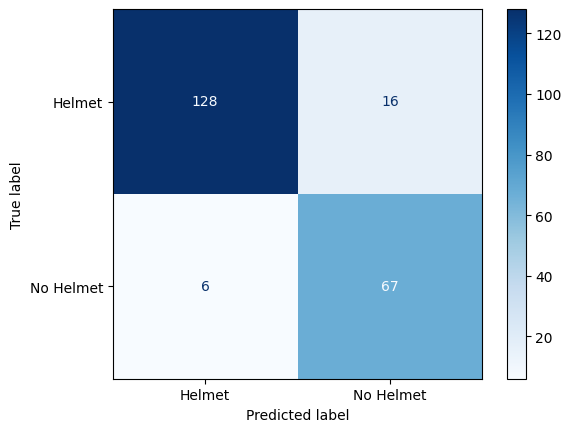

In [55]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Helmet", "No Helmet"]
)

disp.plot(cmap="Blues")
plt.show()

In [56]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Helmet", "No Helmet"]
    )
)

              precision    recall  f1-score   support

      Helmet       0.96      0.89      0.92       144
   No Helmet       0.81      0.92      0.86        73

    accuracy                           0.90       217
   macro avg       0.88      0.90      0.89       217
weighted avg       0.91      0.90      0.90       217



###saving model

In [57]:
from pathlib import Path

#create model directory path
model_path=Path("models")
model_path.mkdir(parents=True,exist_ok=True)

#create model save
model_name="Helmvision.pth"
model_path_save= model_path/model_name

#saving model state dict
print(f"saving model to {model_path_save}")
torch.save(obj=model_tl.state_dict(),f=model_path_save)

saving model to models/Helmvision.pth


In [58]:
torch.manual_seed(42)
from PIL import Image
import matplotlib.pyplot as plt
import torch
class_names = ["Helmet", "No Helmet"]

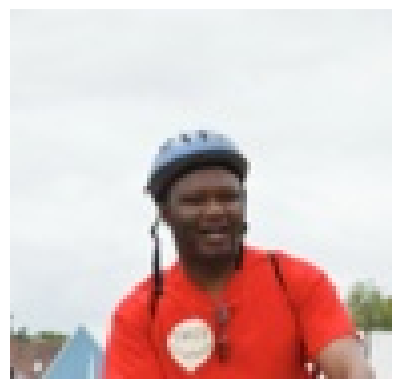

In [72]:
image_path = "dataset/test/helmet/helmet_120.jpg"

image = Image.open(image_path).convert("RGB")

plt.imshow(image)
plt.axis("off")
plt.show()

In [74]:
image_tensor = eval_transform(image)
print(image_tensor.shape)

torch.Size([3, 224, 224])


In [75]:
image_tensor = image_tensor.unsqueeze(0)
print(image_tensor.shape)
image_tensor = image_tensor.to(device)

torch.Size([1, 3, 224, 224])


In [76]:
model_tl.eval()

with torch.inference_mode():
    logits = model_tl(image_tensor)

probs = torch.softmax(logits, dim=1)

print(probs)

tensor([[0.9761, 0.0239]], device='cuda:0')


In [77]:
pred_idx = torch.argmax(probs, dim=1).item()

prediction = class_names[pred_idx]

confidence = probs[0][pred_idx].item() * 100

print("Prediction:", prediction)
print("Confidence:", round(confidence, 2), "%")

Prediction: Helmet
Confidence: 97.61 %


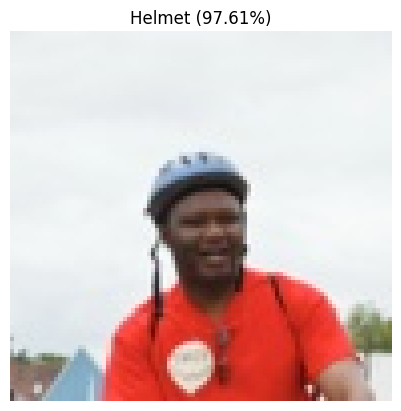

In [78]:
plt.imshow(image)
plt.title(
    f"{prediction} ({confidence:.2f}%)"
)
plt.axis("off")
plt.show()

###openCV integration

In [82]:
import cv2

# Fix: Change "test.jpg" to a valid image path that exists in your dataset
img = cv2.imread("dataset/test/helmet/helmet_120.jpg")
# Make sure to convert BGR to RGB for matplotlib if you plan to display it later
# img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Uncomment if you want to display with plt

In [83]:
print(type(img))

<class 'numpy.ndarray'>


In [84]:
print(img.shape)

(92, 95, 3)


In [85]:
img_rgb = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2RGB
)

In [86]:
from PIL import Image

pil_img = Image.fromarray(img_rgb)

In [88]:
image_tensor = eval_transform(pil_img)
print(image_tensor.shape)

torch.Size([3, 224, 224])


In [89]:
image_tensor = image_tensor.unsqueeze(0)
image_tensor = image_tensor.to(device)

In [90]:
model_tl.eval()

with torch.inference_mode():
    logits = model_tl(image_tensor)

probs = torch.softmax(logits, dim=1)
pred_idx = torch.argmax(probs, dim=1).item()

class_names = ["Helmet", "No Helmet"]

prediction = class_names[pred_idx]

array([[[236, 235, 231],
        [237, 236, 232],
        [237, 236, 232],
        ...,
        [240, 237, 233],
        [239, 236, 232],
        [239, 236, 232]],

       [[237, 236, 232],
        [238, 237, 233],
        [238, 237, 233],
        ...,
        [241, 238, 234],
        [240, 237, 233],
        [240, 237, 233]],

       [[239, 238, 234],
        [239, 238, 234],
        [240, 239, 235],
        ...,
        [242, 239, 235],
        [241, 238, 234],
        [241, 238, 234]],

       ...,

       [[ 82,  86, 104],
        [127, 133, 152],
        [117, 125, 148],
        ...,
        [233, 235, 235],
        [231, 235, 230],
        [232, 233, 229]],

       [[ 66,  68,  79],
        [140, 141, 155],
        [147, 150, 165],
        ...,
        [231, 235, 236],
        [230, 232, 232],
        [234, 234, 234]],

       [[ 76,  77,  87],
        [148, 149, 159],
        [173, 170, 185],
        ...,
        [230, 234, 235],
        [230, 232, 232],
        [234, 233, 237]]], dtype=uint8)
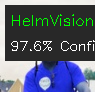

In [93]:
if prediction == "Helmet":
    status = "SAFE"
    color = (0,255,0)      # Green
else:
    status = "HELMET REQUIRED"
    color = (0,0,255)      # Red

cv2.rectangle(
    img,
    (5, 5),
    (220, 60),
    (40, 40, 40),
    -1
)

cv2.putText(
    img,
    f"HelmVision | {status}",
    (10, 25),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.5,
    color,
    1
)

cv2.putText(
    img,
    f"{confidence:.1f}% Confidence",
    (10, 50),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.45,
    (255,255,255),
    1
)